In [4]:
!pip install seaborn matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_product=pd.read_csv("olist_products_dataset.csv")
df_product.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [6]:
df_product.info()
df_product.isnull().sum()
df_product_cleaned=df_product.dropna()
the_deleted_rows=len(df_product)-len(df_product_cleaned)
print(f"the total rows:{len(df_product)}")
print(f"rows after deleting:{len(df_product_cleaned)}")
print(f"the deleted rows:{(the_deleted_rows)}")

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB
the total rows:32951
rows after deleting:32340
the deleted rows:611


In [7]:
print(df_product_cleaned.duplicated(subset=['product_id']).sum())


0


In [8]:
# عرض أسماء الفئات الفريدة وترتيبها أبجدياً
unique_categories = df_product_cleaned['product_category_name'].unique()
print(unique_categories)

# معرفة عدد الفئات المختلفة
print(f"\nعدد الفئات الفريدة: {len(unique_categories)}")

<StringArray>
[                                    'perfumaria',
                                          'artes',
                                  'esporte_lazer',
                                          'bebes',
                          'utilidades_domesticas',
                          'instrumentos_musicais',
                                     'cool_stuff',
                               'moveis_decoracao',
                               'eletrodomesticos',
                                     'brinquedos',
                                'cama_mesa_banho',
               'construcao_ferramentas_seguranca',
                         'informatica_acessorios',
                                   'beleza_saude',
                               'malas_acessorios',
                             'ferramentas_jardim',
                              'moveis_escritorio',
                                     'automotivo',
                                    'eletronicos',
                 

In [9]:
df_product_cleaned["product_category_name"]=df_product_cleaned["product_category_name"].str.lower()
df_product_cleaned["product_category_name"]=df_product_cleaned["product_category_name"].str.strip()
print(df_product_cleaned)


                             product_id              product_category_name  \
0      1e9e8ef04dbcff4541ed26657ea517e5                         perfumaria   
1      3aa071139cb16b67ca9e5dea641aaa2f                              artes   
2      96bd76ec8810374ed1b65e291975717f                      esporte_lazer   
3      cef67bcfe19066a932b7673e239eb23d                              bebes   
4      9dc1a7de274444849c219cff195d0b71              utilidades_domesticas   
...                                 ...                                ...   
32946  a0b7d5a992ccda646f2d34e418fff5a0                   moveis_decoracao   
32947  bf4538d88321d0fd4412a93c974510e6  construcao_ferramentas_iluminacao   
32948  9a7c6041fa9592d9d9ef6cfe62a71f8c                    cama_mesa_banho   
32949  83808703fc0706a22e264b9d75f04a2e             informatica_acessorios   
32950  106392145fca363410d287a815be6de4                    cama_mesa_banho   

       product_name_lenght  product_description_lenght  product

In [10]:
summary=df_product_cleaned.describe()
print(summary)

       product_name_lenght  product_description_lenght  product_photos_qty  \
count         32340.000000                32340.000000        32340.000000   
mean             48.476592                  771.492393            2.188961   
std              10.245699                  635.124831            1.736787   
min               5.000000                    4.000000            1.000000   
25%              42.000000                  339.000000            1.000000   
50%              51.000000                  595.000000            1.000000   
75%              57.000000                  972.000000            3.000000   
max              76.000000                 3992.000000           20.000000   

       product_weight_g  product_length_cm  product_height_cm  \
count      32340.000000       32340.000000       32340.000000   
mean        2276.956586          30.854545          16.958813   
std         4279.291845          16.955965          13.636115   
min            0.000000           7.0

In [11]:
zero_weight=df_product_cleaned[df_product_cleaned['product_weight_g']==0]
print(len(zero_weight))

4


In [12]:
df_product_cleaned=df_product_cleaned[df_product_cleaned["product_weight_g"]>0]
print(df_product_cleaned.min())
# we have fnished from the first one

product_id                    00066f42aeeb9f3007548bb9d3f33c38
product_category_name                agro_industria_e_comercio
product_name_lenght                                        5.0
product_description_lenght                                 4.0
product_photos_qty                                         1.0
product_weight_g                                           2.0
product_length_cm                                          7.0
product_height_cm                                          2.0
product_width_cm                                           6.0
dtype: object


In [13]:
df_payment=pd.read_csv('olist_order_payments_dataset.csv')
display(df_payment.head())
df_payment.info()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [14]:
unique_categories=df_payment["payment_type"].unique()
print(unique_categories)

<StringArray>
['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined']
Length: 5, dtype: str


In [15]:
sum=df_payment.describe()
print(sum)

       payment_sequential  payment_installments  payment_value
count       103886.000000         103886.000000  103886.000000
mean             1.092679              2.853349     154.100380
std              0.706584              2.687051     217.494064
min              1.000000              0.000000       0.000000
25%              1.000000              1.000000      56.790000
50%              1.000000              1.000000     100.000000
75%              1.000000              4.000000     171.837500
max             29.000000             24.000000   13664.080000


In [16]:
counter_duplicated=df_payment.duplicated().sum()
print(counter_duplicated)

0


In [17]:
total_not_defined=df_payment[df_payment["payment_type"]=="not_defined"]

print(total_not_defined)

                               order_id  payment_sequential payment_type  \
51280  4637ca194b6387e2d538dc89b124b0ee                   1  not_defined   
57411  00b1cb0320190ca0daa2c88b35206009                   1  not_defined   
94427  c8c528189310eaa44a745b8d9d26908b                   1  not_defined   

       payment_installments  payment_value  
51280                     1            0.0  
57411                     1            0.0  
94427                     1            0.0  


In [18]:
df_payment=df_payment[df_payment["payment_type"]!="not_defined"]

In [19]:
df_item=pd.read_csv("olist_order_items_dataset.csv")
display(df_item.head())
df_item.info()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [20]:
df_merge1=pd.merge(df_item,df_product_cleaned ,on="product_id",how="inner")
display(df_merge1.head())

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [21]:
df_merge2=pd.merge(df_merge1,df_payment,on='order_id',how="inner")
display(df_merge2.head())

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,1,credit_card,2,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,1,credit_card,3,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,1,credit_card,5,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,1,credit_card,2,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,1,credit_card,3,218.04


In [22]:
payment_count=df_merge2['payment_type'].value_counts()
print(payment_count)

payment_type
credit_card    85527
boleto         22549
voucher         6156
debit_card      1662
Name: count, dtype: int64


In [23]:
installments_analysis=df_merge2.groupby('payment_installments')['payment_value'].mean()
print(installments_analysis)

payment_installments
0     106.190000
1     132.491444
2     134.555373
3     153.889574
4     179.506386
5     198.126569
6     235.504229
7     194.625582
8     311.122213
9     203.449125
10    431.107114
11    124.530800
12    323.769571
13    148.677222
14    166.521250
15    423.653804
16    395.081429
17    174.522857
18    493.345263
20    568.072857
21    267.428000
22    228.710000
23    236.480000
24    801.737941
Name: payment_value, dtype: float64


In [24]:
top_revenue = df_merge2.groupby('product_category_name')['payment_value'].sum().sort_values(ascending=False)
print(top_revenue.head(10))

product_category_name
cama_mesa_banho           1710872.33
beleza_saude              1657373.12
informatica_acessorios    1585330.45
moveis_decoracao          1430176.39
relogios_presentes        1429216.68
esporte_lazer             1392127.56
utilidades_domesticas     1094758.13
automotivo                 852294.33
ferramentas_jardim         838280.75
cool_stuff                 779698.00
Name: payment_value, dtype: float64


In [25]:
category_analysis=df_merge2.groupby("product_category_name")["payment_value"].agg(["sum","count"])
print(category_analysis.sort_values(ascending=False, by='sum').head(10))


                               sum  count
product_category_name                    
cama_mesa_banho         1710872.33  11815
beleza_saude            1657373.12   9972
informatica_acessorios  1585330.45   8082
moveis_decoracao        1430176.39   8744
relogios_presentes      1429216.68   6201
esporte_lazer           1392127.56   8945
utilidades_domesticas   1094758.13   7355
automotivo               852294.33   4379
ferramentas_jardim       838280.75   4574
cool_stuff               779698.00   3987


/tmp/ipykernel_40347/3816081391.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10_revenue, x='product_category_name', y='sum', palette='viridis')


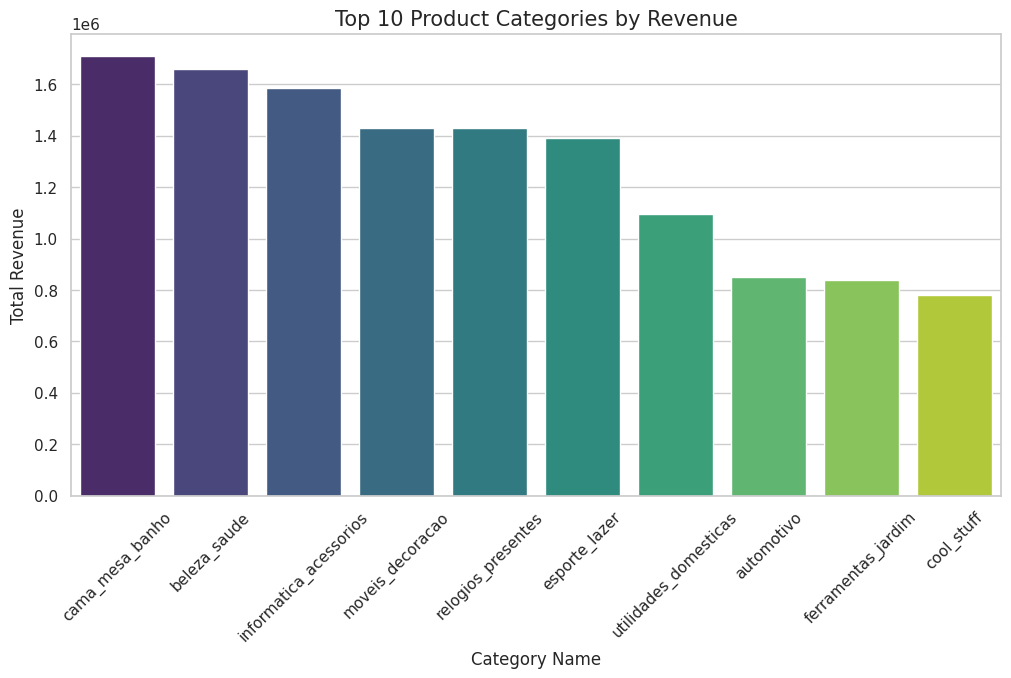

In [26]:
top_10_revenue = category_analysis.sort_values(by='sum', ascending=False).head(10).reset_index()
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=top_10_revenue, x='product_category_name', y='sum', palette='viridis')

plt.xticks(rotation=45)
plt.title('Top 10 Product Categories by Revenue', fontsize=15)
plt.xlabel('Category Name')
plt.ylabel('Total Revenue')

plt.show()

In [28]:
plt.savefig('top_10_revenue.png', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>